<a href="https://colab.research.google.com/github/creon-shit/typ/blob/main/typ03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CNN

100%|██████████| 9.91M/9.91M [00:00<00:00, 35.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.06MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.8MB/s]


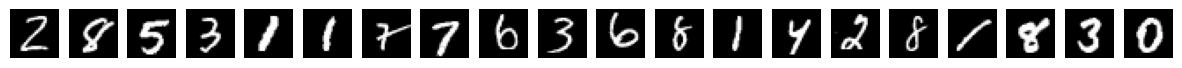

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 64
num_classes = 10
epochs = 10
learning_rate = 1e-4 # 0.0001

# Dataset
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transforms.ToTensor(), download=True)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size = BATCH_SIZE, shuffle = False)
iterator = iter(train_loader)
images, labels = next(iterator)
fig, axes = plt.subplots(1,20, figsize=(15, 15))
for i in range(20):
  axes[i].imshow(images[i][0], cmap = 'gray')
  axes[i].set_axis_off()
fig.show()

In [3]:

class ConvNet(nn.Module):
  def __init__(self,in_channels,h1,h2,num_classes):
    super().__init__()
    self.conv1=nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=3, stride=1, padding=1)
    self.poll1=nn.MaxPool2d(2)
    self.conv2=nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
    self.pool2=nn.MaxPool2d(2)
    self.fc1=nn.Linear(7*7*64,256)




  def forward(self, x):
    x=F.relu(self.conv1(x))
    x=self.poll1(x)
    x=F.relu(self.conv2(x))
    x=self.pool2(x)
    x=x.view(-1,7*7*64)
    output=self.fc1(x)


    return output